In [31]:
# Import Libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
# Set Path
models_folder = "../models"
processed_folder = "../data/processed"
input_file = os.path.join(processed_folder, "nhs_ae_full_2020_2026.csv")
lstm_predictions_file = os.path.join(processed_folder, "lstm_forecast_predictions.csv")

In [33]:
df = pd.read_csv(input_file)
df["period"] = pd.to_datetime(df["period"])
df = df.sort_values(["org_code", "period"]).reset_index(drop=True)

df = df[df["total_attendances"] > 0].copy()
df.head()

,period,org_code,parent_org,org_name,aande_attendances_type_1,aande_attendances_type_2,aande_attendances_other_aande_department,attendances_over_4hrs_type_1,attendances_over_4hrs_type_2,attendances_over_4hrs_other_department,...,attendances_over_4hrs_booked_appointments_other_department,total_attendances,total_booked_attendances,total_over_4hrs,total_booked_over_4hrs,total_dta_waits,total_emergency_admissions,over_4hr_rate,booked_over_4hr_rate,admission_rate
0,2020-04-01,8J094,NHS ENGLAND MIDLANDS,BADGER LTD,0,0,58,0,0,0,...,0.0,58,0.0,0,0.0,0,0,0.000000,0.0,0.0
71,2025-03-01,A5D4Q,NHS ENGLAND MIDLANDS,NEMS UTC,0,0,3681,0,0,1464,...,0.0,3681,0.0,1464,0.0,0,0,0.397718,0.0,0.0
72,2025-04-01,A5D4Q,NHS ENGLAND MIDLANDS,NEMS UTC,0,0,3399,0,0,777,...,0.0,3399,0.0,777,0.0,0,0,0.228597,0.0,0.0
73,2025-05-01,A5D4Q,NHS ENGLAND MIDLANDS,NEMS UTC,0,0,3404,0,0,776,...,0.0,3404,0.0,776,0.0,0,0,0.227967,0.0,0.0
74,2025-06-01,A5D4Q,NHS ENGLAND MIDLANDS,NEMS UTC,0,0,3731,0,0,722,...,0.0,3731,0.0,722,0.0,0,0,0.193514,0.0,0.0


In [34]:
sequence_length = 12
target_col = "total_attendances"

In [35]:

scaler = MinMaxScaler()
df["scaled_attendances"] = scaler.fit_transform(df[["total_attendances"]])

In [36]:
df[["total_attendances", "scaled_attendances"]].head()

,total_attendances,scaled_attendances
0,58,0.001230
71,3681,0.079422
72,3399,0.073335
73,3404,0.073443
74,3731,0.080501


In [37]:
def create_sequences(group, seq_len=12):
    values = group["scaled_attendances"].values
    periods = group["period"].values
    org_codes = group["org_code"].values
    org_names = group["org_name"].values

    X, y, meta = [], [], []

    for i in range(seq_len, len(values)):
        X.append(values[i-seq_len:i])
        y.append(values[i])
        meta.append((org_codes[i], org_names[i], periods[i]))

    return X, y, meta

In [38]:
X_all, y_all, meta_all = [], [], []

for _, group in df.groupby("org_code"):
    if len(group) > sequence_length:
        X_group, y_group, meta_group = create_sequences(group, sequence_length)
        X_all.extend(X_group)
        y_all.extend(y_group)
        meta_all.extend(meta_group)

X_all = np.array(X_all)
y_all = np.array(y_all)

X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

print(X_all.shape, y_all.shape)

(10972, 12, 1) (10972,)


In [39]:
meta_df = pd.DataFrame(meta_all, columns=["org_code", "org_name", "period"])
meta_df["period"] = pd.to_datetime(meta_df["period"])

In [40]:
# Final validation checks before LSTM training
print("Rows:", len(df))
print("Unique organisations:", df["org_code"].nunique())
print("Date range:", df["period"].min(), "to", df["period"].max())
print("Sequence length:", sequence_length)

Rows: 13567
Unique organisations: 225
Date range: 2020-04-01 00:00:00 to 2026-02-01 00:00:00
Sequence length: 12


In [41]:
split_date = pd.Timestamp("2025-04-01")

train_idx = meta_df["period"] < split_date
test_idx = meta_df["period"] >= split_date

X_train = X_all[train_idx]
X_test = X_all[test_idx]
y_train = y_all[train_idx]
y_test = y_all[test_idx]

meta_test = meta_df.loc[test_idx].reset_index(drop=True)

print(X_train.shape, X_test.shape)

(8966, 12, 1) (2006, 12, 1)


In [42]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

In [43]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0034 - val_loss: 9.9767e-04
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_loss: 8.5104e-04
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - val_loss: 7.6155e-04
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.7610e-04 - val_loss: 7.1836e-04
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.2464e-04 - val_loss: 6.4436e-04
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.8278e-04 - val_loss: 6.0219e-04
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.2199e-04 - val_loss: 6.0958e-04
Epoch 9/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.3450e-04 - val_loss: 5.8891e-04
Epoch 10/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.9621e-04 - val_loss: 5.5601e-04
Epoch 11/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.8267e-04 - val_l

In [44]:
y_pred_scaled = model.predict(X_test).flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_actual = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [45]:
lstm_mae = mean_absolute_error(y_test_actual, y_pred_actual)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
lstm_r2 = r2_score(y_test_actual, y_pred_actual)

print(f"LSTM MAE: {lstm_mae:,.2f}")
print(f"LSTM RMSE: {lstm_rmse:,.2f}")
print(f"LSTM R²: {lstm_r2:.4f}")

LSTM MAE: 528.64
LSTM RMSE: 838.55
LSTM R²: 0.9921


In [46]:
lstm_results = meta_test.copy()
lstm_results["actual_total_attendances"] = y_test_actual
lstm_results["predicted_total_attendances"] = y_pred_actual

lstm_results.head()

,org_code,org_name,period,actual_total_attendances,predicted_total_attendances
0,AAH,TETBURY HOSPITAL TRUST LTD,2025-04-01,536.0,523.625488
1,AAH,TETBURY HOSPITAL TRUST LTD,2025-05-01,524.0,479.609924
2,AAH,TETBURY HOSPITAL TRUST LTD,2025-06-01,611.0,460.277985
3,AAH,TETBURY HOSPITAL TRUST LTD,2025-07-01,688.0,486.651611
4,AAH,TETBURY HOSPITAL TRUST LTD,2025-08-01,482.0,524.404846


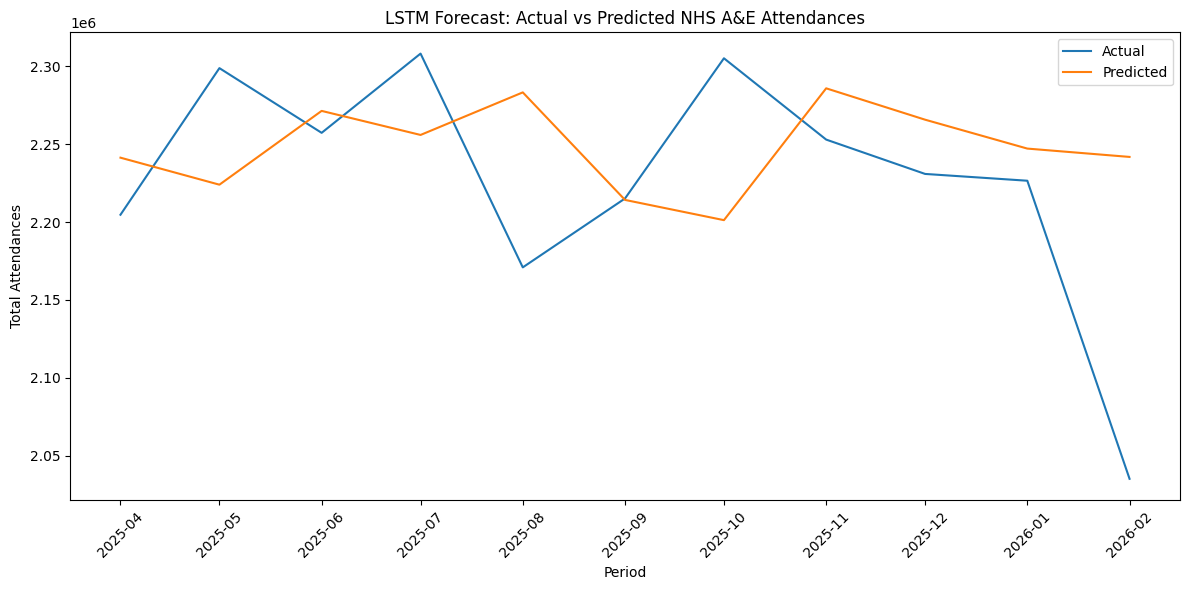

In [47]:
monthly_lstm = (
    lstm_results.groupby("period", as_index=False)
    .agg(
        actual_total_attendances=("actual_total_attendances", "sum"),
        predicted_total_attendances=("predicted_total_attendances", "sum")
    )
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_lstm["period"], monthly_lstm["actual_total_attendances"], label="Actual")
plt.plot(monthly_lstm["period"], monthly_lstm["predicted_total_attendances"], label="Predicted")
plt.title("LSTM Forecast: Actual vs Predicted NHS A&E Attendances")
plt.xlabel("Period")
plt.ylabel("Total Attendances")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
lstm_results.to_csv(lstm_predictions_file, index=False)
print(f"Saved LSTM predictions to: {lstm_predictions_file}")

Saved LSTM predictions to: ../data/processed/lstm_forecast_predictions.csv


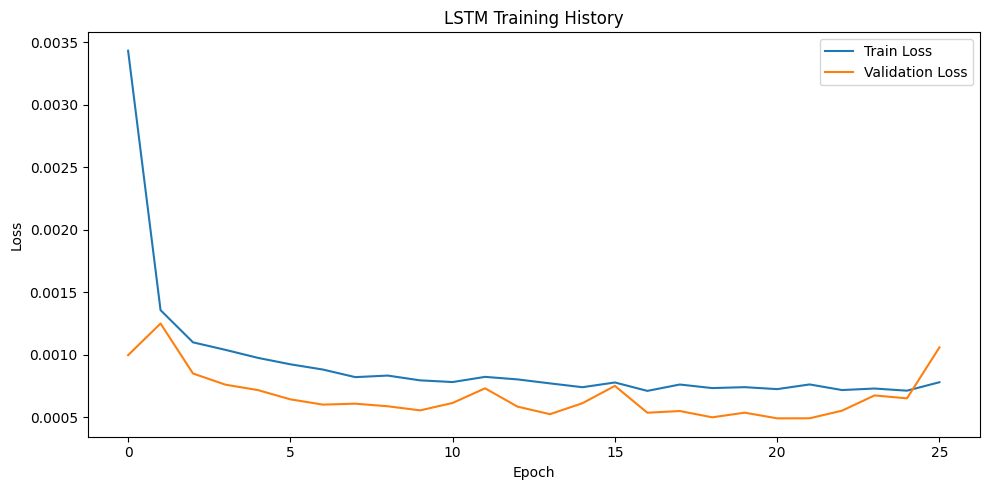

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
lstm_metrics = pd.DataFrame([{
    "model": "LSTM",
    "MAE": lstm_mae,
    "RMSE": lstm_rmse,
    "R2": lstm_r2
}])

lstm_metrics.to_csv("../data/processed/lstm_metrics.csv", index=False)
print("Saved LSTM metrics.")

Saved LSTM metrics.


In [51]:
# Save trained LSTM model artifact
model.save(os.path.join(models_folder, "lstm_model.keras"))
print("Saved LSTM model.")

Saved LSTM model.
